<a href="https://colab.research.google.com/github/autratec/FlanT5_HFEmbedding_LlamaIndex/blob/main/luner_Lander_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# this is how this note works. the first one the core the traning two model and show teh different. the later to is the real gif to show the landing.

In [ ]:
!apt-get update -qq
!apt-get install -y -qq swig


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package swig4.0.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ubuntu1_all.deb ...
Unpacking swig (4.0.2-1ubuntu1) ...
Setting up swig4.0 (4.0.2-1ubuntu1) ...
Setting up swig (4.0.2-1ubuntu1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!pip install -q stable-baselines3 gymnasium[box2d]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 65.9 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute



🚀 Training: ppo_baseline


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_r

Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 86.7     |
|    ep_rew_mean     | -165     |
| time/              |          |
|    fps             | 1097     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Streaming output truncated to the last 5000 lines.
|    value_loss           | 1.17e+03    |
-----------------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 114          |
|    ep_rew_mean          | -106         |
| time/                   |              |
|    fps                  | 606          |
|    iterations           | 8            |
|    time_elapsed         | 26           |
|    total_timesteps      | 16384        |
| train/                  |              |
|    approx_kl            | 0.0048762006 |
|    clip_fraction        | 0.0133       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.27        |
|    explained_variance   | -0.283       |
|    learning_rate        | 0.0003       |
|    loss                 | 1.34e+03     |
|    n_updates            | 70           |
|    policy_gradient_loss | -0.0048      |
|    value_loss           | 2.04e+03     |
-----

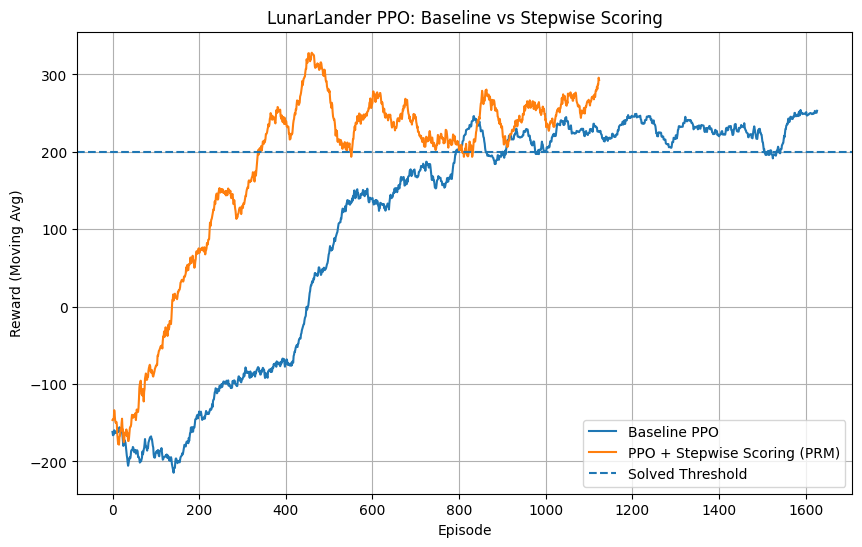


✅ All done. Data saved to comparison_data.npz


In [ ]:
# ===============================
# Colab Setup
# ===============================
#!pip install -q stable-baselines3 gymnasium[box2d]

# ===============================
# Imports
# ===============================
import os
import gymnasium as gym
import numpy as np
import torch
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor

# ===============================
# Global Config (CRITICAL FOR FAIR COMPARISON)
# ===============================
SEED = 42
TOTAL_TIMESTEPS = 500_000
ENV_ID = "LunarLander-v3"

# PPO hyperparameters (FIXED)
PPO_CONFIG = dict(
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
)

# ===============================
# Reproducibility
# ===============================
def set_global_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

# ===============================
# Reward Logger Callback
# ===============================
class EpisodeRewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self.episode_lengths = []

    def _on_step(self) -> bool:
        infos = self.locals["infos"]
        dones = self.locals["dones"]

        if dones[0] and "episode" in infos[0]:
            self.episode_rewards.append(infos[0]["episode"]["r"])
            self.episode_lengths.append(infos[0]["episode"]["l"])

        return True

# ===============================
# STEP-WISE SCORING (PRM) Wrapper
# ===============================
class StepwiseRewardWrapper(gym.Wrapper):
    """
    Example PRM-style step-wise reward shaping.
    IMPORTANT:
    - Does NOT change env dynamics
    - ONLY modifies reward
    """

    def __init__(self, env):
        super().__init__(env)
        self.prev_shaping = None

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.prev_shaping = None
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        # ===== PRM-style stepwise shaping =====
        # Observation unpack (LunarLander)
        x, y, vx, vy, angle, angular_v, left_c, right_c = obs

        shaping = (
            -100 * np.sqrt(x * x + y * y)
            - 100 * np.sqrt(vx * vx + vy * vy)
            - 100 * abs(angle)
            + 10 * left_c
            + 10 * right_c
        )

        if self.prev_shaping is not None:
            reward += shaping - self.prev_shaping

        self.prev_shaping = shaping
        # =====================================

        return obs, reward, terminated, truncated, info

# ===============================
# Training Function
# ===============================
def train(run_name: str, use_prm: bool):
    print(f"\n🚀 Training: {run_name}")
    set_global_seed(SEED)

    env = gym.make(ENV_ID)
    env.reset(seed=SEED)

    if use_prm:
        env = StepwiseRewardWrapper(env)

    env = Monitor(env)

    model = PPO(
        "MlpPolicy",
        env,
        verbose=1,
        seed=SEED,
        **PPO_CONFIG,
    )

    callback = EpisodeRewardCallback()

    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=callback,
    )

    model.save(f"{run_name}.zip")

    return callback.episode_rewards

# ===============================
# Plotting
# ===============================
def plot_comparison(baseline_rewards, prm_rewards, window=50):
    def moving_avg(x):
        return np.convolve(x, np.ones(window) / window, mode="valid")

    plt.figure(figsize=(10, 6))

    plt.plot(moving_avg(baseline_rewards), label="Baseline PPO")
    plt.plot(moving_avg(prm_rewards), label="PPO + Stepwise Scoring (PRM)")

    plt.axhline(200, linestyle="--", label="Solved Threshold")
    plt.xlabel("Episode")
    plt.ylabel("Reward (Moving Avg)")
    plt.title("LunarLander PPO: Baseline vs Stepwise Scoring")
    plt.legend()
    plt.grid(True)
    plt.show()

# ===============================
# Main Execution
# ===============================
if __name__ == "__main__":
    baseline_rewards = train("ppo_baseline", use_prm=False)
    prm_rewards = train("ppo_prm", use_prm=True)

    plot_comparison(baseline_rewards, prm_rewards)

    np.savez(
        "comparison_data.npz",
        baseline=baseline_rewards,
        prm=prm_rewards,
    )

    print("\n✅ All done. Data saved to comparison_data.npz")


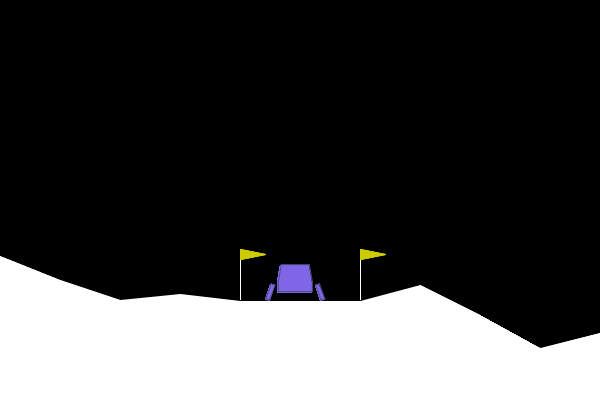

✅ Episode 10 ended at step 230


/usr/local/lib/python3.12/dist-packages/imageio/plugins/pillow.py:410: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


🎬 GIF saved as lunarlander_10_baseline.gif


In [ ]:
import gymnasium as gym
from stable_baselines3 import PPO
from IPython.display import clear_output, display
from PIL import Image
import imageio
import numpy as np

# Load model
model = PPO.load("ppo_baseline")

# Create env
env = gym.make("LunarLander-v3", render_mode="rgb_array")

frames = []

NUM_EPISODES = 10
MAX_STEPS = 1000
FPS = 30

for ep in range(NUM_EPISODES):
    obs, info = env.reset()
    print(f"🚀 Episode {ep+1}/{NUM_EPISODES}")

    for step in range(MAX_STEPS):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)

        frame = env.render()
        frames.append(frame)

        # Optional: live preview (can comment out for speed)
        img = Image.fromarray(frame)
        clear_output(wait=True)
        display(img)

        if terminated or truncated:
            print(f"✅ Episode {ep+1} ended at step {step}")

            # Add a short pause between episodes in the GIF
            for _ in range(int(FPS * 0.5)):  # 0.5 second pause
                frames.append(frame)
            break

env.close()

# Save one combined GIF
imageio.mimsave(
    "lunarlander_10_baseline.gif",
    frames,
    fps=FPS
)

print("🎬 GIF saved as lunarlander_10_baseline.gif")


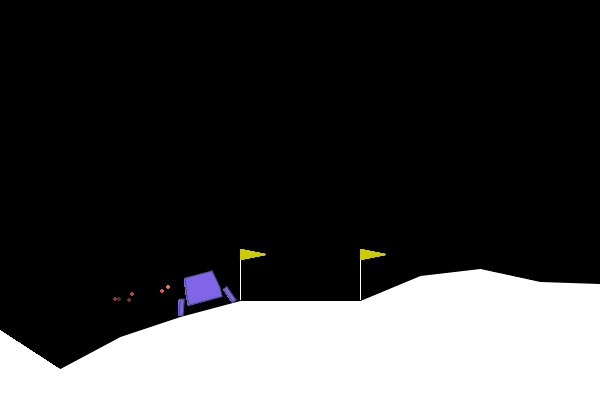

✅ Episode 10 ended at step 409
🎬 GIF saved as lunarlander_10_prm.gif


In [ ]:
import gymnasium as gym
from stable_baselines3 import PPO
from IPython.display import clear_output, display
from PIL import Image
import imageio
import numpy as np

# Load model
model = PPO.load("ppo_prm")

# Create env
env = gym.make("LunarLander-v3", render_mode="rgb_array")

frames = []

NUM_EPISODES = 10
MAX_STEPS = 1000
FPS = 30

for ep in range(NUM_EPISODES):
    obs, info = env.reset()
    print(f"🚀 Episode {ep+1}/{NUM_EPISODES}")

    for step in range(MAX_STEPS):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)

        frame = env.render()
        frames.append(frame)

        # Optional: live preview (can comment out for speed)
        img = Image.fromarray(frame)
        clear_output(wait=True)
        display(img)

        if terminated or truncated:
            print(f"✅ Episode {ep+1} ended at step {step}")

            # Add a short pause between episodes in the GIF
            for _ in range(int(FPS * 0.5)):  # 0.5 second pause
                frames.append(frame)
            break

env.close()

# Save one combined GIF
imageio.mimsave(
    "lunarlander_10_prm.gif",
    frames,
    fps=FPS
)

print("🎬 GIF saved as lunarlander_10_prm.gif")
